Run_ID,Sim_Type,Status,Directory,Trajectory,HDF5,Frame_Count
20260915204048,Thermalization,Complete,/exp/e961/data/MDsims-data/pnichols/SQL/Thermalization/20260915204048,/exp/e961/data/MDsims-data/pnichols/SQL/Thermalization/20260915204048/trajectory.gsd,/exp/e961/data/MDsims-data/pnichols/SQL/Thermalization/20260915204048/run.hdf5,6


Run_ID,Run_Signature,N_Cells,Nsteps,Current_Nstep,ElapsedTime,StartTime,EndTime,Last_Update_Time,Sim_Type,Status,Stop_Reason,Status_Message,Notes
20260915204048,149a1c52584fe54b686da2c6e1dbce2a0cb5a1173ab1d12dd8b5e5f69e12ad8a,40,200000,200000,202.878179,2026-09-15 20:40:50.245913,2026-09-15 20:44:30.846346,2026-09-15 20:44:30.846346,Thermalization,Complete,None,None,None


Run_ID,File_Location,Clone_Run_ID,Clone_Frame_ID,Therm_kT,Therm_Seed,Density_Start,Density_End,BoxLength_Start,BoxLength_End,dt,Nsteps,This_LJ_Time,Cumulative_LJ_Time,Ensemble,T_Set,P_Set,LJ_r_cut,LJ_r_on,LJ_Mode,Phase_Separation_Status,Phase_Separation_Method,Phase_Separation_Method_Version,rho_liquid,rho_liquid_unc,rho_gas,rho_gas_unc,V_liquid,V_liquid_unc,V_gas,V_gas_unc,Phase_Fit_Status,Phase_Fit_Method,Phase_Fit_Method_Version,Summary_Start_Step,Summary_End_Step,Summary_Num_Samples,Pressure_Mean,Pressure_Std,Pressure_SEM,PE_Per_Particle_Mean,PE_Per_Particle_Std,PE_Per_Particle_SEM,Num_Frames,N_Cells
20260915204048,Thermalization/20260915204048,None,None,1.000000,1,0.500000,0.500000,80.000000,80.000000,0.002000,200000,400.000000,400.000000,NVT,1.000000,None,2.500000,2.000000,xplor,Separated,voxel_histogram,voxel_low_density_fraction_v1,0.613256,0.000440,0.057231,0.000682,407036.911363,1419.415614,104963.088637,1419.415614,Complete,averaged_voxel_histogram_mixture,terminal_5_saved_frames_log_stride_10_v2,101000,200000,100,0.023452,0.005854,0.000585,-3.683460,0.010460,0.001046,6,40


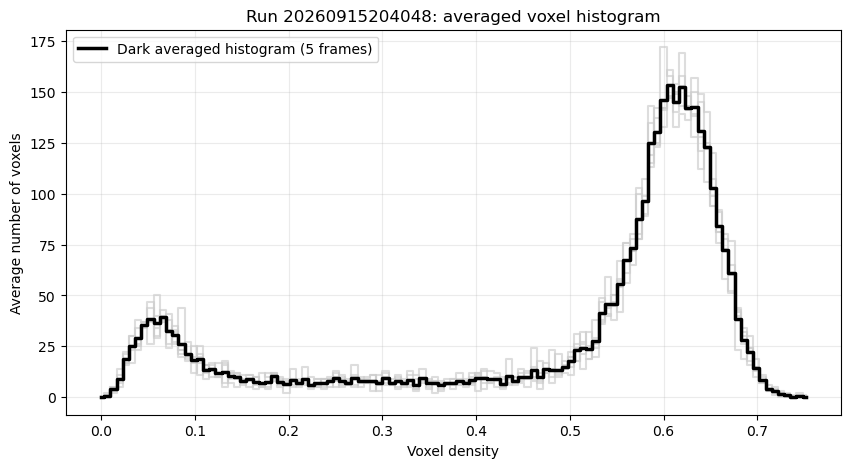

Histogram source: saved in run.hdf5
Voxel volume: 151.704


In [68]:
import numpy as np
import matplotlib.pyplot as plt
from md_Helpers.voxel_fit import averaged_trajectory_voxel_histogram


import importlib
import md_Helpers

importlib.reload(md_Helpers)

from md_Helpers import open_run

run = open_run("20260915165726")
run = open_run("20260915204048")
run.info()


saved_fit = run._phase_fit_attributes()

if "observed_counts" in saved_fit and "density_axis" in saved_fit:
    histogram = saved_fit
    source = "saved in run.hdf5"
else:
    histogram = averaged_trajectory_voxel_histogram(
        run.trajectory_path,
        n_cells=int(run.master_row["N_Cells"]),
        frame_indices=run.phase_average_frame_ids(),
    )
    source = "reconstructed from the saved analysis frames"

density_axis = np.asarray(histogram["density_axis"], dtype=float)
count_axis = np.asarray(histogram["count_axis"], dtype=float)
observed = np.asarray(histogram["observed_counts"], dtype=float)
voxel_volume = float(histogram["voxel_volume"])
individual = np.asarray(
    histogram["individual_histograms"], dtype=float
)
frames_used = individual.shape[0]

fig, ax = plt.subplots(figsize=(10, 5))

for frame_histogram in individual:
    ax.step(
        density_axis, frame_histogram,
        where="mid", color="0.8", alpha=0.65,
    )

ax.step(
    density_axis, observed,
    where="mid", color="black", linewidth=2.5,
    label=f"Dark averaged histogram ({frames_used} frames)",
)

ax.set_xlabel("Voxel density")
ax.set_ylabel("Average number of voxels")
ax.set_title(f"Run {run.run_id}: averaged voxel histogram")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

print(f"Histogram source: {source}")
print(f"Voxel volume: {voxel_volume:.6g}")

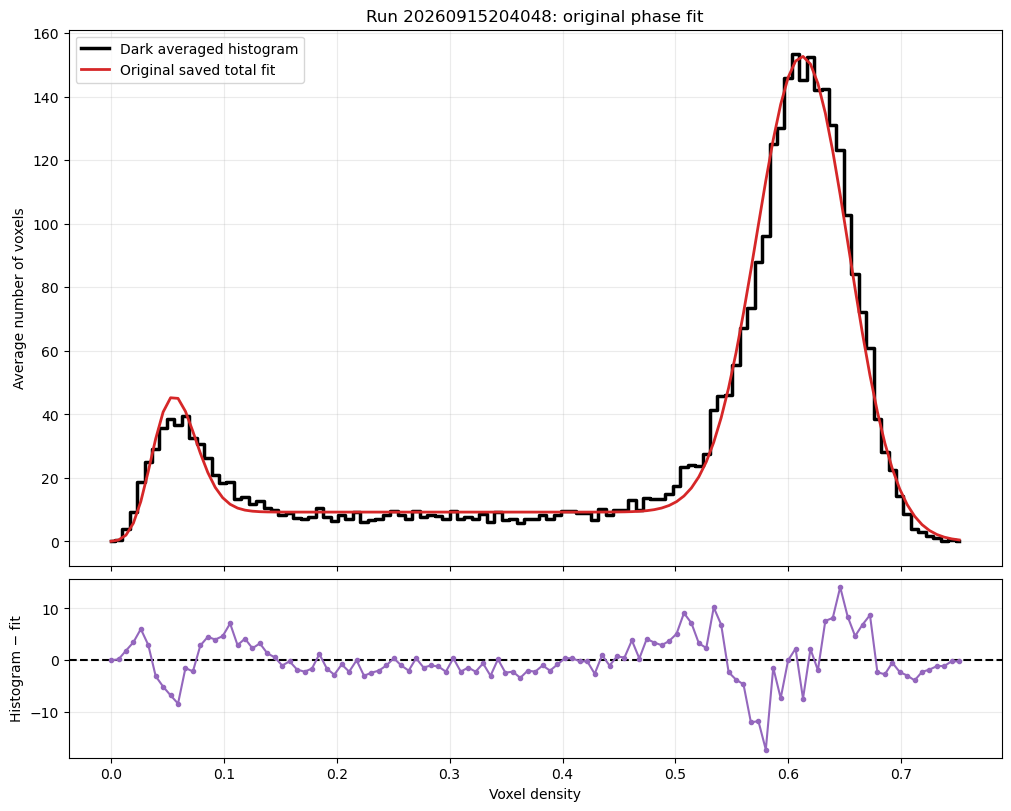

In [69]:
import numpy as np
import matplotlib.pyplot as plt

saved_fit = run._phase_fit_attributes()

required = ["density_axis", "observed_counts", "model_counts"]
missing = [key for key in required if key not in saved_fit]
if missing:
    raise KeyError(
        f"This run does not contain the original saved fit arrays: {missing}"
    )

density = np.asarray(saved_fit["density_axis"], dtype=float)
observed = np.asarray(saved_fit["observed_counts"], dtype=float)
model = np.asarray(saved_fit["model_counts"], dtype=float)

if not (len(density) == len(observed) == len(model)):
    raise ValueError("Saved histogram and fit arrays have different lengths.")

residual = observed - model

fig, (ax_fit, ax_resid) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
    constrained_layout=True,
)

ax_fit.step(
    density, observed,
    where="mid", color="black", linewidth=2.5,
    label="Dark averaged histogram",
)
ax_fit.plot(
    density, model,
    color="tab:red", linewidth=2,
    label="Original saved total fit",
)
ax_fit.set_ylabel("Average number of voxels")
ax_fit.set_title(f"Run {run.run_id}: original phase fit")
ax_fit.grid(alpha=0.25)
ax_fit.legend()

ax_resid.axhline(0, color="black", linestyle="--")
ax_resid.plot(density, residual, "o-", markersize=3, color="tab:purple")
ax_resid.set_xlabel("Voxel density")
ax_resid.set_ylabel("Histogram − fit")
ax_resid.grid(alpha=0.25)

plt.show()

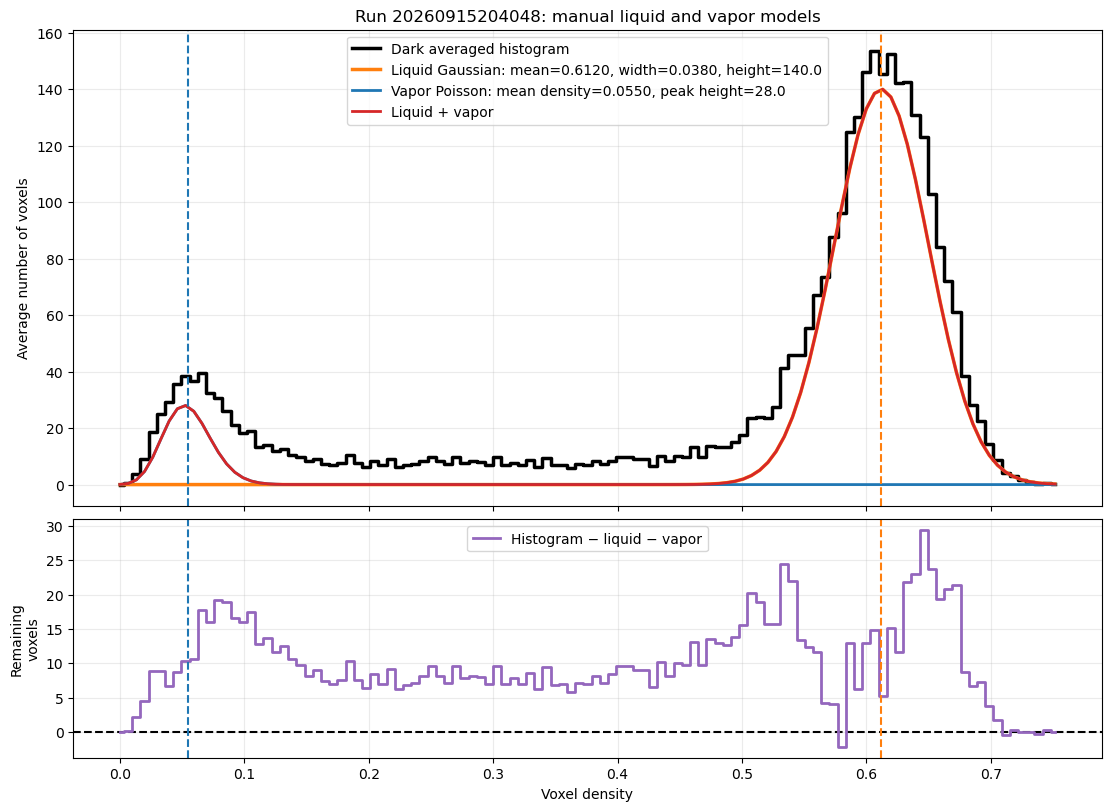

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
from md_Helpers.voxel_fit import averaged_trajectory_voxel_histogram

# Liquid Gaussian
gaussian_height = 140.0
gaussian_center = 0.612
gaussian_width = 0.038

# Vapor Poisson model: change these two values
vapor_mean_density = 0.055
vapor_peak_height = 28.0

saved_fit = run._phase_fit_attributes()

if all(
    key in saved_fit
    for key in [
        "observed_counts",
        "density_axis",
        "count_axis",
        "voxel_volume",
    ]
):
    histogram = saved_fit
else:
    histogram = averaged_trajectory_voxel_histogram(
        run.trajectory_path,
        n_cells=int(run.master_row["N_Cells"]),
        frame_indices=run.phase_average_frame_ids(),
    )

density = np.asarray(histogram["density_axis"], dtype=float)
count_axis = np.asarray(histogram["count_axis"], dtype=int)
observed = np.asarray(histogram["observed_counts"], dtype=float)
voxel_volume = float(histogram["voxel_volume"])

if gaussian_width <= 0:
    raise ValueError("gaussian_width must be positive.")
if vapor_mean_density <= 0 or vapor_peak_height < 0:
    raise ValueError(
        "Vapor mean density must be positive and peak height nonnegative."
    )

liquid_gaussian = gaussian_height * np.exp(
    -0.5 * ((density - gaussian_center) / gaussian_width) ** 2
)

vapor_mean_count = vapor_mean_density * voxel_volume
vapor_shape = poisson.pmf(count_axis, vapor_mean_count)

if vapor_shape.max() <= 0:
    raise ValueError("Vapor Poisson peak falls outside the histogram bins.")

vapor_model = (
    vapor_peak_height * vapor_shape / vapor_shape.max()
)

liquid_and_vapor = liquid_gaussian + vapor_model
remainder = observed - liquid_and_vapor

fig, (ax, ax_remainder) = plt.subplots(
    2, 1,
    figsize=(11, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.5]},
    constrained_layout=True,
)

ax.step(
    density, observed,
    where="mid", color="black", linewidth=2.5,
    label="Dark averaged histogram",
)
ax.plot(
    density, liquid_gaussian,
    color="tab:orange", linewidth=2.5,
    label=(
        f"Liquid Gaussian: mean={gaussian_center:.4f}, "
        f"width={gaussian_width:.4f}, "
        f"height={gaussian_height:.1f}"
    ),
)
ax.plot(
    density, vapor_model,
    color="tab:blue", linewidth=2,
    label=(
        f"Vapor Poisson: mean density={vapor_mean_density:.4f}, "
        f"peak height={vapor_peak_height:.1f}"
    ),
)
ax.plot(
    density, liquid_and_vapor,
    color="tab:red", linewidth=2,
    label="Liquid + vapor",
)
ax.axvline(
    gaussian_center,
    color="tab:orange",
    linestyle="--",
    linewidth=1.5,
)
ax.axvline(
    vapor_mean_density,
    color="tab:blue",
    linestyle="--",
    linewidth=1.5,
)
ax.set_ylabel("Average number of voxels")
ax.set_title(f"Run {run.run_id}: manual liquid and vapor models")
ax.grid(alpha=0.25)
ax.legend()

ax_remainder.axhline(0, color="black", linestyle="--")
ax_remainder.step(
    density, remainder,
    where="mid", color="tab:purple", linewidth=2,
    label="Histogram − liquid − vapor",
)
ax_remainder.axvline(
    gaussian_center,
    color="tab:orange",
    linestyle="--",
    linewidth=1.5,
)
ax_remainder.axvline(
    vapor_mean_density,
    color="tab:blue",
    linestyle="--",
    linewidth=1.5,
)
ax_remainder.set_xlabel("Voxel density")
ax_remainder.set_ylabel("Remaining\nvoxels")
ax_remainder.grid(alpha=0.25)
ax_remainder.legend()

plt.show()

Fixed plateau height:       10.0000
Fixed plateau left:         0.0700
Fixed plateau left width:   0.0050
Fitted plateau right:       0.5515
Fitted plateau right width: 0.0038
Fitted shoulder height:     10.2110
Fitted shoulder rise:       0.4928
Fitted shoulder rise width: 0.0111
Fitted shoulder fall:       0.6300
Fitted shoulder fall width: 0.0500
Interface-region RMSE: 3.53 voxels


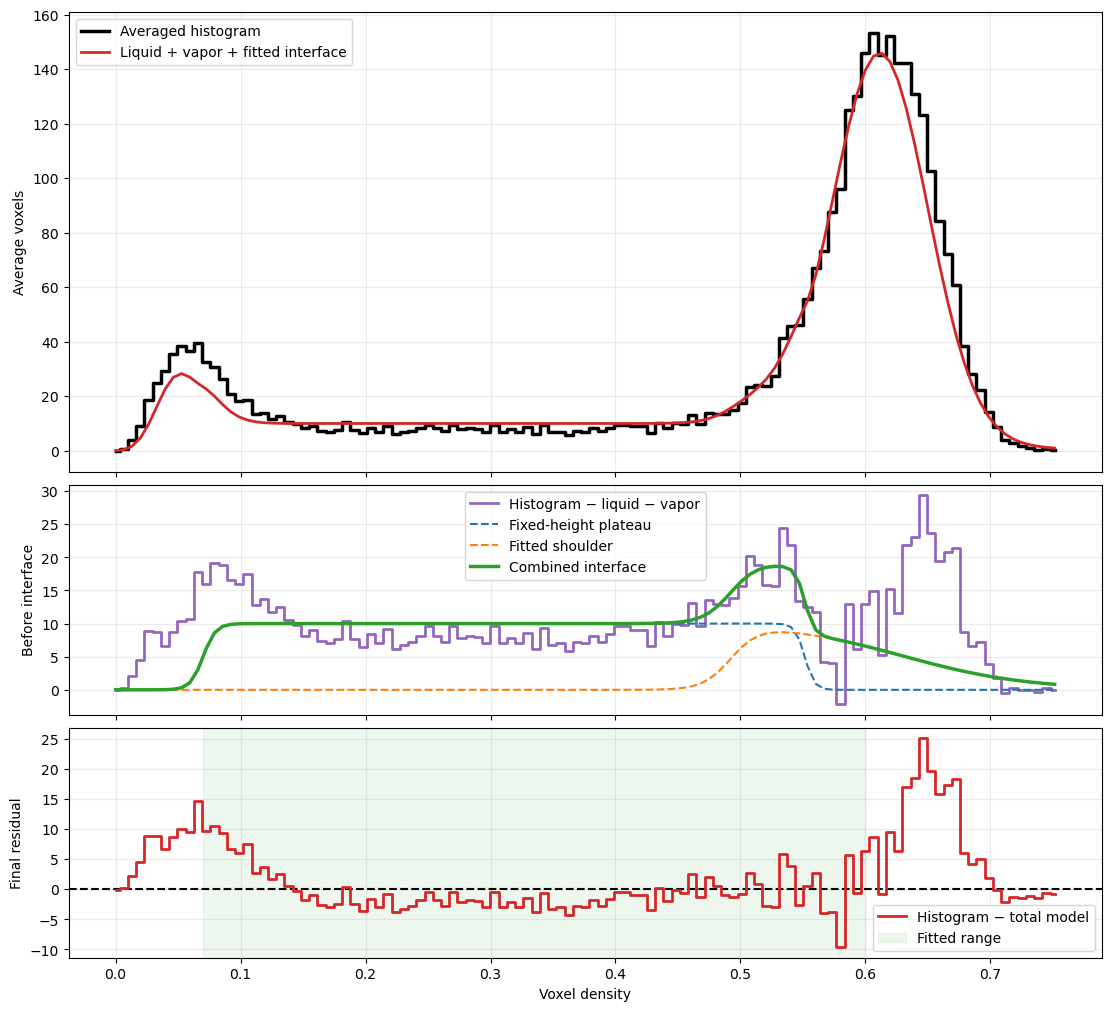

In [71]:
from scipy.optimize import least_squares
from scipy.special import expit

# Fixed by you
plateau_height = 10.0
plateau_left = 0.07
plateau_left_width = 0.005

# Fit only this density range
interface_fit_start = 0.07
interface_fit_end = 0.60
fit_mask = (
    (density >= interface_fit_start)
    & (density <= interface_fit_end)
)

def interface_parts(x, parameters):
    (
        plateau_right,
        plateau_right_width,
        shoulder_height,
        shoulder_rise,
        shoulder_rise_width,
        shoulder_fall,
        shoulder_fall_width,
    ) = parameters

    plateau_part = (
        plateau_height
        * expit((x - plateau_left) / plateau_left_width)
        * expit((plateau_right - x) / plateau_right_width)
    )

    shoulder_part = (
        shoulder_height
        * expit((x - shoulder_rise) / shoulder_rise_width)
        * expit((shoulder_fall - x) / shoulder_fall_width)
    )

    return plateau_part, shoulder_part

def fit_residuals(parameters):
    plateau_part, shoulder_part = interface_parts(
        density[fit_mask], parameters
    )
    return (
        plateau_part + shoulder_part
        - remainder[fit_mask]
    )

fit = least_squares(
    fit_residuals,
    x0=[
        0.575,  # plateau_right
        0.012,  # plateau_right_width
        28.0,   # shoulder_height
        0.515,  # shoulder_rise
        0.015,  # shoulder_rise_width
        0.570,  # shoulder_fall
        0.008,  # shoulder_fall_width
    ],
    bounds=(
        [0.45, 0.003,  0.0, 0.38, 0.003, 0.55, 0.003],
        [0.63, 0.060, 80.0, 0.57, 0.080, 0.63, 0.050],
    ),
    max_nfev=5000,
)

if not fit.success:
    raise RuntimeError(f"Interface fit failed: {fit.message}")

(
    plateau_right,
    plateau_right_width,
    shoulder_height,
    shoulder_rise,
    shoulder_rise_width,
    shoulder_fall,
    shoulder_fall_width,
) = fit.x

plateau, shoulder = interface_parts(density, fit.x)
interface_model = plateau + shoulder
total_model = liquid_gaussian + vapor_model + interface_model
final_residual = observed - total_model

print(f"Fixed plateau height:       {plateau_height:.4f}")
print(f"Fixed plateau left:         {plateau_left:.4f}")
print(f"Fixed plateau left width:   {plateau_left_width:.4f}")
print(f"Fitted plateau right:       {plateau_right:.4f}")
print(f"Fitted plateau right width: {plateau_right_width:.4f}")
print(f"Fitted shoulder height:     {shoulder_height:.4f}")
print(f"Fitted shoulder rise:       {shoulder_rise:.4f}")
print(f"Fitted shoulder rise width: {shoulder_rise_width:.4f}")
print(f"Fitted shoulder fall:       {shoulder_fall:.4f}")
print(f"Fitted shoulder fall width: {shoulder_fall_width:.4f}")
print(
    "Interface-region RMSE: "
    f"{np.sqrt(np.mean(fit.fun**2)):.2f} voxels"
)

fig, (ax_total, ax_before, ax_after) = plt.subplots(
    3, 1,
    figsize=(11, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.5, 1.5]},
    constrained_layout=True,
)

ax_total.step(
    density, observed, where="mid",
    color="black", linewidth=2.5,
    label="Averaged histogram",
)
ax_total.plot(
    density, total_model,
    color="tab:red", linewidth=2,
    label="Liquid + vapor + fitted interface",
)
ax_total.set_ylabel("Average voxels")
ax_total.legend()
ax_total.grid(alpha=0.25)

ax_before.step(
    density, remainder, where="mid",
    color="tab:purple", linewidth=2,
    label="Histogram − liquid − vapor",
)
ax_before.plot(
    density, plateau,
    color="tab:blue", linestyle="--",
    label="Fixed-height plateau",
)
ax_before.plot(
    density, shoulder,
    color="tab:orange", linestyle="--",
    label="Fitted shoulder",
)
ax_before.plot(
    density, interface_model,
    color="tab:green", linewidth=2.5,
    label="Combined interface",
)
ax_before.set_ylabel("Before interface")
ax_before.legend()
ax_before.grid(alpha=0.25)

ax_after.axhline(0, color="black", linestyle="--")
ax_after.step(
    density, final_residual, where="mid",
    color="tab:red", linewidth=2,
    label="Histogram − total model",
)
ax_after.axvspan(
    interface_fit_start, interface_fit_end,
    color="tab:green", alpha=0.08,
    label="Fitted range",
)
ax_after.set_xlabel("Voxel density")
ax_after.set_ylabel("Final residual")
ax_after.legend()
ax_after.grid(alpha=0.25)

plt.show()

Gaussian mean minimum: 0.4500
Pure-liquid minimum: 10% = 338 voxels per frame


,Model,rho_gas,rho_liquid,liquid_width,gas_weight,liquid_weight,interface_weight,Full_RMSE,Interface_RMSE,AIC_approx,Successful_starts
2,two_beta,0.047416,0.625939,0.035176,0.026775,0.359225,0.614000,2.643059,2.225946,138108.154265,26
1,beta,0.051898,0.616783,0.038901,0.055279,0.582081,0.362640,3.440320,3.135443,138191.359109,19
0,uniform,0.057260,0.613262,0.040772,0.089574,0.679732,0.230694,4.417843,4.124080,138368.146316,11


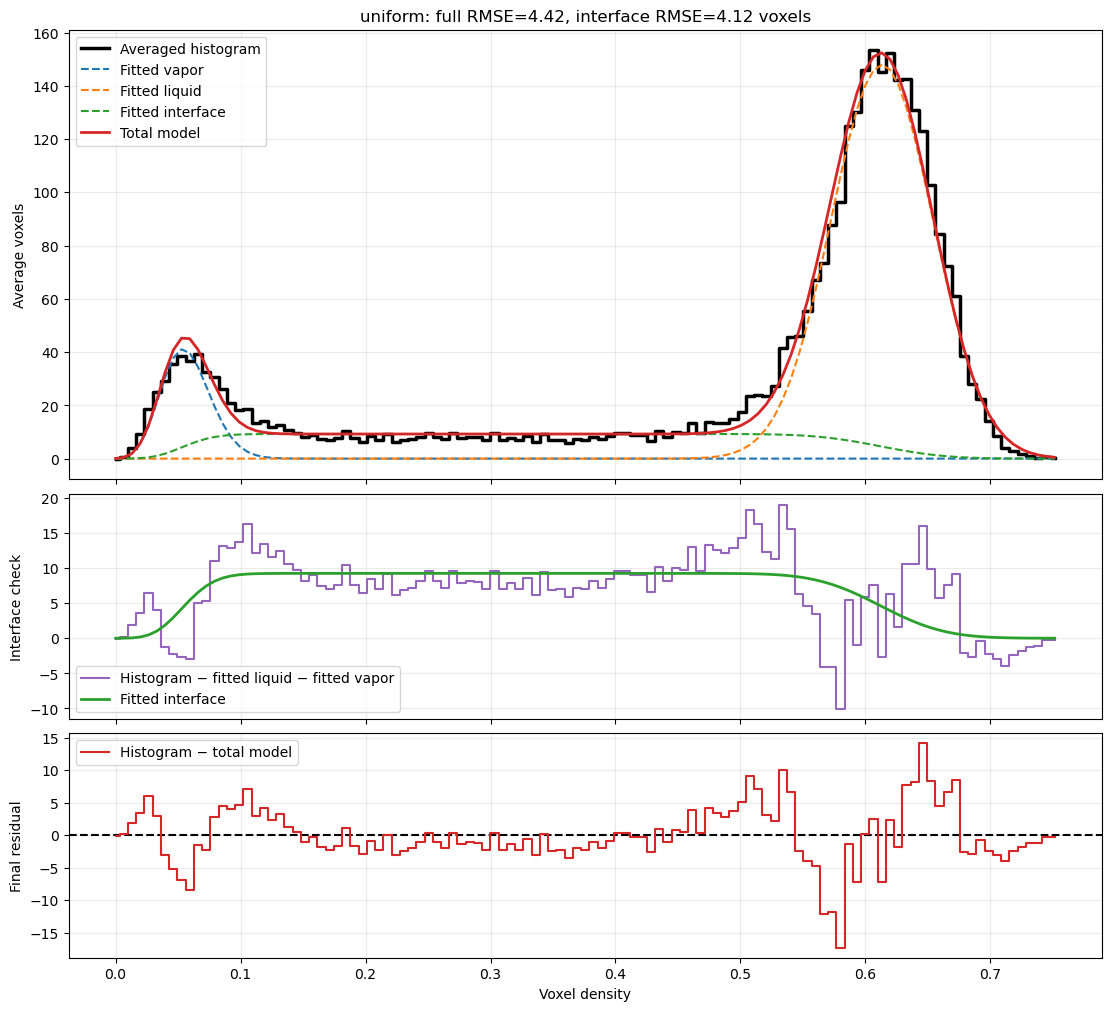

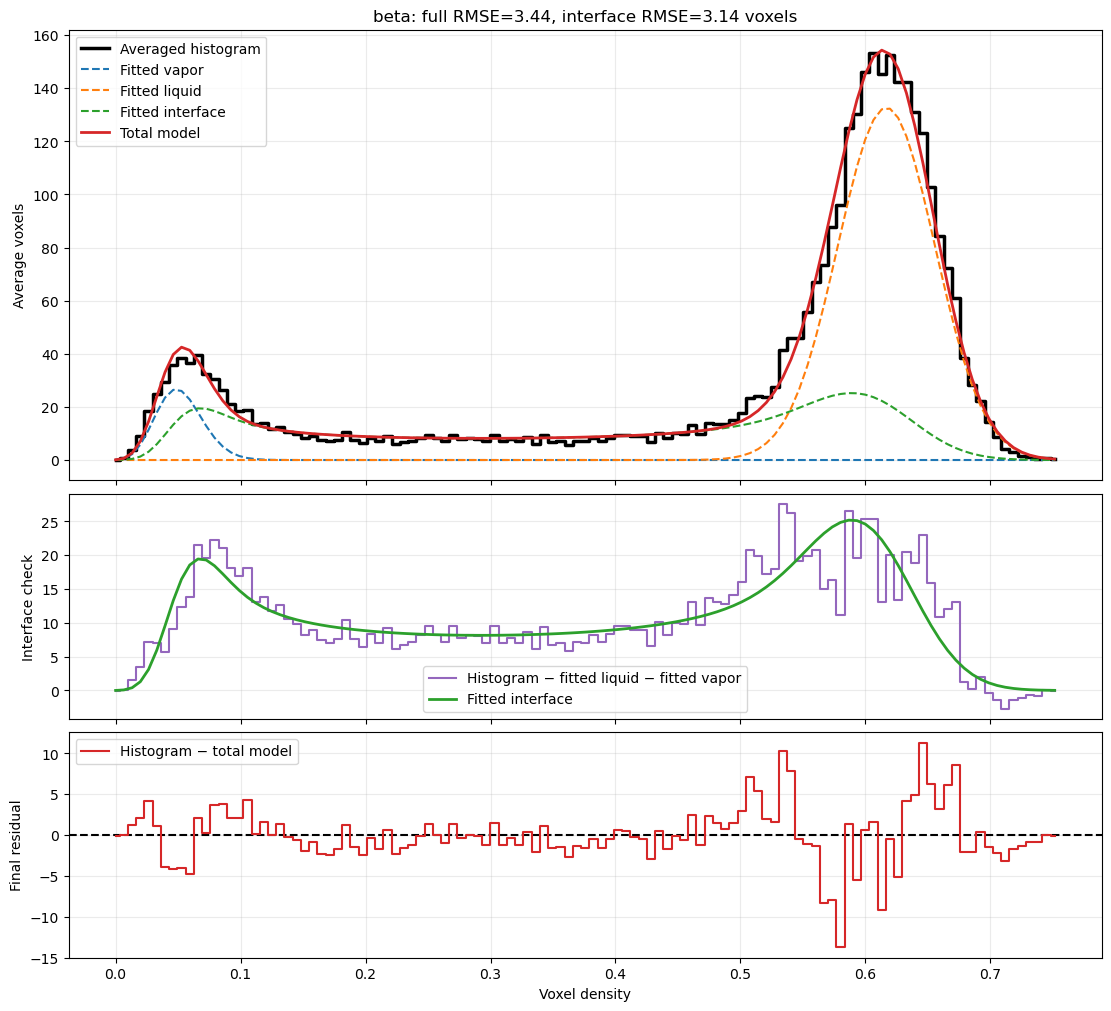

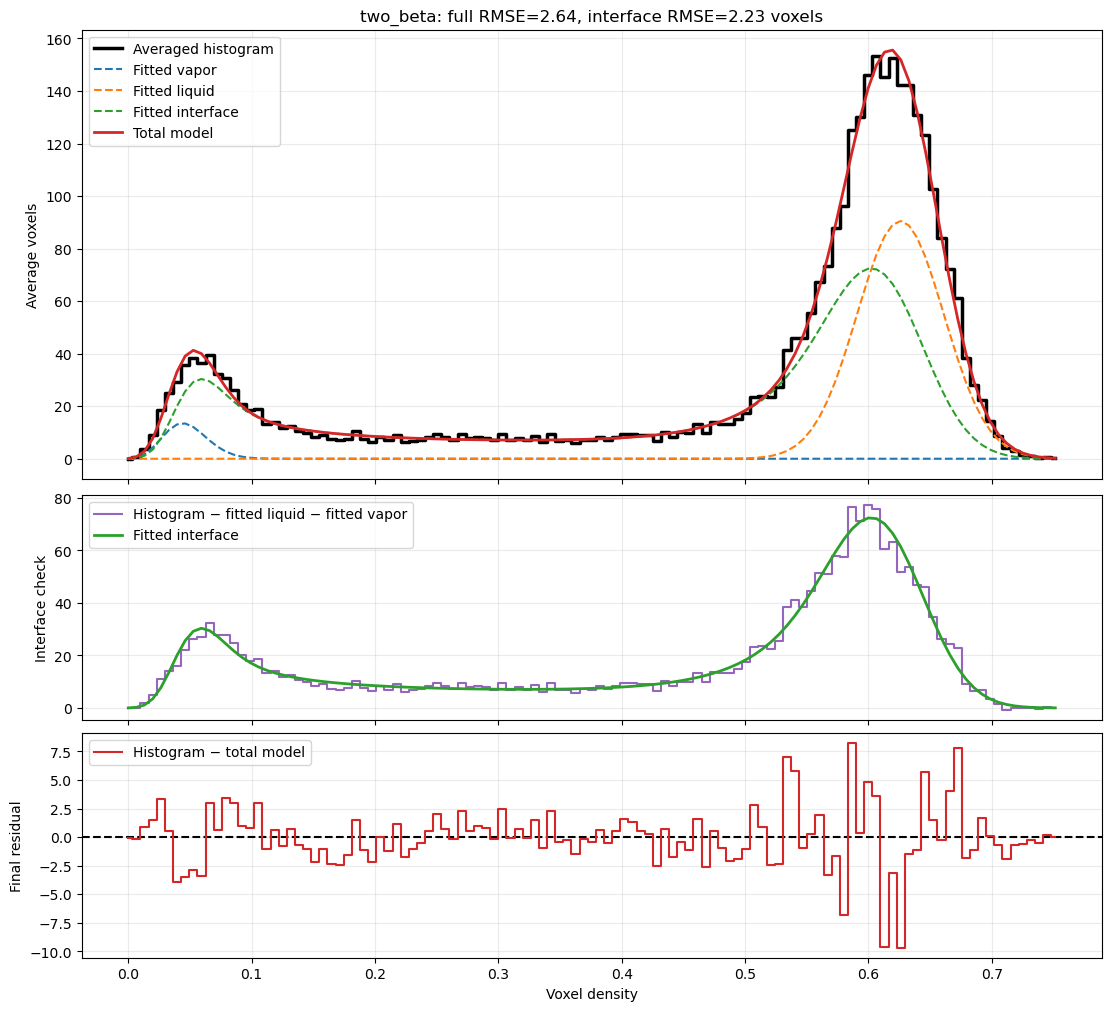

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.special import expit, logsumexp
from scipy.stats import beta, norm, poisson
from IPython.display import display
from md_Helpers.voxel_fit import averaged_trajectory_voxel_histogram

# Increase these for a broader search (and longer runtime).
starts_per_model = {
    "uniform": 12,
    "beta": 20,
    "two_beta": 28,
}
number_of_fractions = 60
random_seed = 20260915

# ------------------------------------------------------------
# Load the same averaged histogram used by the saved phase fit
# ------------------------------------------------------------

saved_fit = run._phase_fit_attributes()

if all(
    key in saved_fit
    for key in [
        "observed_counts", "density_axis",
        "count_axis", "voxel_volume",
    ]
):
    histogram = saved_fit
else:
    histogram = averaged_trajectory_voxel_histogram(
        run.trajectory_path,
        n_cells=int(run.master_row["N_Cells"]),
        frame_indices=run.phase_average_frame_ids(),
    )

observed = np.asarray(
    histogram["observed_counts"], dtype=float
)
density = np.asarray(
    histogram["density_axis"], dtype=float
)
k = np.asarray(
    histogram["count_axis"], dtype=int
)
voxel_volume = float(histogram["voxel_volume"])

if len(k) != len(observed) or not np.array_equal(
    k, np.arange(len(k))
):
    raise ValueError("Expected consecutive voxel-count bins.")

frames_used = len(run.phase_average_frame_ids())
voxels_per_frame = float(observed.sum())

minimum_liquid_weight = 0.10
minimum_liquid_peak_ratio = 1.25  # liquid peak ≥ 1.05 × shoulder peak
right_shoulder_start = 0.45

density_start = float(run.state_row["Density_Start"])
minimum_rho_liquid = 0.90 * density_start
minimum_liquid_weight = 0.10

rho_liquid_upper = 0.720
if minimum_rho_liquid >= rho_liquid_upper:
    raise ValueError(
        f"Minimum liquid mean {minimum_rho_liquid:.4f} "
        f"is not below upper bound {rho_liquid_upper:.4f}. "
        "Increase rho_liquid_upper."
    )

print(f"Gaussian mean minimum: {minimum_rho_liquid:.4f}")
print(
    "Pure-liquid minimum: "
    f"{minimum_liquid_weight:.0%} = "
    f"{minimum_liquid_weight * voxels_per_frame:.0f} "
    "voxels per frame"
)









fit_counts = observed * frames_used

fractions = (
    np.arange(number_of_fractions) + 0.5
) / number_of_fractions

lower_edges = k.astype(float) - 0.5
lower_edges[0] = -np.inf
upper_edges = k.astype(float) + 0.5
fft_length = 2 * len(k) - 1

def normalize(probabilities, axis=-1):
    probabilities = np.clip(probabilities, 0, None)
    return probabilities / np.maximum(
        probabilities.sum(axis=axis, keepdims=True),
        1e-300,
    )

def softmax_weights(
    gas_logit,
    liquid_logit,
    liquid_pmf,
    interface_pmf,
):
    shoulder_mask = density >= right_shoulder_start

    liquid_shape_peak = liquid_pmf.max()
    shoulder_shape_peak = interface_pmf[
        shoulder_mask
    ].max()

    # Reserve at least 10% for liquid, so vapor cannot
    # consume the entire voxel budget.
    gas_weight = (
        (1.0 - minimum_liquid_weight)
        * expit(gas_logit)
    )
    available = 1.0 - gas_weight

    # This is the liquid weight needed for:
    # liquid peak ≥ ratio × right-interface peak.
    peak_required_weight = (
        available
        * minimum_liquid_peak_ratio
        * shoulder_shape_peak
        / (
            liquid_shape_peak
            + minimum_liquid_peak_ratio
            * shoulder_shape_peak
        )
    )

    liquid_floor = max(
        minimum_liquid_weight,
        peak_required_weight,
    )

    liquid_weight = (
        liquid_floor
        + (available - liquid_floor)
        * expit(liquid_logit)
    )
    interface_weight = (
        available - liquid_weight
    )

    return gas_weight, liquid_weight, interface_weight

def beta_weights(alpha, beta_shape):
    weights = beta.pdf(
        fractions, alpha, beta_shape
    )
    return normalize(weights)

def model_components(parameters, model_name):
    (
        rho_gas,
        rho_liquid,
        liquid_width,
        gas_logit,
        liquid_logit,
    ) = parameters[:5]

    gas_mean_count = rho_gas * voxel_volume
    liquid_mean_count = rho_liquid * voxel_volume
    liquid_width_count = liquid_width * voxel_volume

    # Pure vapor: particle counts are Poisson.
    gas_pmf = normalize(
        poisson.pmf(k, gas_mean_count)
    )

    # Pure liquid: discretized Gaussian particle counts.
    liquid_pmf = normalize(
        norm.cdf(
            upper_edges,
            loc=liquid_mean_count,
            scale=liquid_width_count,
        )
        - norm.cdf(
            lower_edges,
            loc=liquid_mean_count,
            scale=liquid_width_count,
        )
    )

    # For each interface liquid fraction, combine vapor counts
    # and liquid counts by convolution.
    f = fractions[:, None]

    partial_gas = poisson.pmf(
        k[None, :],
        (1.0 - f) * gas_mean_count,
    )

    partial_liquid_sigma = (
        np.sqrt(f) * liquid_width_count
    )
    partial_liquid = (
        norm.cdf(
            upper_edges[None, :],
            loc=f * liquid_mean_count,
            scale=partial_liquid_sigma,
        )
        - norm.cdf(
            lower_edges[None, :],
            loc=f * liquid_mean_count,
            scale=partial_liquid_sigma,
        )
    )

    # Vectorized convolution along the count axis.
    partial_mixed = np.fft.irfft(
        np.fft.rfft(
            partial_gas, n=fft_length, axis=1
        )
        * np.fft.rfft(
            partial_liquid, n=fft_length, axis=1
        ),
        n=fft_length,
        axis=1,
    )[:, :len(k)]
    partial_mixed = normalize(partial_mixed, axis=1)

    if model_name == "uniform":
        fraction_weights = np.full(
            number_of_fractions,
            1.0 / number_of_fractions,
        )

    elif model_name == "beta":
        fraction_weights = beta_weights(
            parameters[5], parameters[6]
        )

    elif model_name == "two_beta":
        first = beta_weights(
            parameters[5], parameters[6]
        )
        second = beta_weights(
            parameters[7], parameters[8]
        )
        first_share = expit(parameters[9])
        fraction_weights = (
            first_share * first
            + (1.0 - first_share) * second
        )

    else:
        raise ValueError(f"Unknown model: {model_name}")

    interface_pmf = normalize(
        fraction_weights @ partial_mixed
    )

    gas_weight, liquid_weight, interface_weight = (
    softmax_weights(
        gas_logit,
        liquid_logit,
        liquid_pmf,
        interface_pmf,
    )
)

    gas_counts = (
        voxels_per_frame * gas_weight * gas_pmf
    )
    liquid_counts = (
        voxels_per_frame * liquid_weight * liquid_pmf
    )
    interface_counts = (
        voxels_per_frame
        * interface_weight
        * interface_pmf
    )

    total_counts = (
        gas_counts + liquid_counts + interface_counts
    )

    return {
        "gas": gas_counts,
        "liquid": liquid_counts,
        "interface": interface_counts,
        "total": total_counts,
        "weights": (
            gas_weight, liquid_weight, interface_weight
        ),
        "fraction_weights": fraction_weights,
    }

def negative_log_likelihood(parameters, model_name):
    components = model_components(
        parameters, model_name
    )
    probabilities = (
        components["total"] / voxels_per_frame
    )
    return -float(
        np.dot(
            fit_counts,
            np.log(np.clip(probabilities, 1e-300, None)),
        )
    )

# Physical parameters are densities; logits control component shares.
common_bounds = [
    (0.005, 0.150),                       # rho_gas
    (minimum_rho_liquid, rho_liquid_upper),  # liquid mean
    (0.015, 0.100),                       # liquid width
    (-8.0, 8.0),                          # gas logit
    (-8.0, 8.0),                          # liquid logit
]

bounds_by_model = {
    "uniform": common_bounds,
    "beta": common_bounds + [
        (0.30, 10.0),  # alpha
        (0.30, 10.0),  # beta
    ],
    "two_beta": common_bounds + [
        (0.30, 10.0),  # first alpha
        (0.30, 10.0),  # first beta
        (0.30, 10.0),  # second alpha
        (0.30, 10.0),  # second beta
        (-8.0, 8.0),   # first-Beta share logit
    ],
}


initial_rho_liquid = (
    minimum_rho_liquid + rho_liquid_upper
) / 2

base_by_model = {
    "uniform": [
        0.055, initial_rho_liquid, 0.038, -2.0, 1.0,
    ],
    "beta": [
        0.055, initial_rho_liquid, 0.038, -2.0, 1.0,
        1.0, 1.0,
    ],
    "two_beta": [
        0.055, initial_rho_liquid, 0.038, -2.0, 1.0,
        1.0, 1.0, 2.0, 0.8, 0.0,
    ],
}

rng = np.random.default_rng(random_seed)
results = {}

for model_name, n_starts in starts_per_model.items():
    bounds = bounds_by_model[model_name]
    starting_points = [
        np.asarray(base_by_model[model_name], dtype=float)
    ]

    # Search broadly, rather than repeatedly perturbing one guess.
    for _ in range(n_starts - 1):
        starting_points.append(np.array([
            rng.uniform(low, high)
            for low, high in bounds
        ]))

    attempts = [
        minimize(
            negative_log_likelihood,
            x0=start,
            args=(model_name,),
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "maxiter": 350,
                "ftol": 1e-10,
            },
        )
        for start in starting_points
    ]

    successful = [
        attempt
        for attempt in attempts
        if attempt.success and np.isfinite(attempt.fun)
    ]

    if not successful:
        raise RuntimeError(
            f"No {model_name} fit converged. "
            f"Best message: "
            f"{min(attempts, key=lambda a: a.fun).message}"
        )

    best = min(
        successful, key=lambda attempt: attempt.fun
    )
    components = model_components(
        best.x, model_name
    )

    residual = observed - components["total"]
    interface_mask = (
        (density >= 0.075)
        & (density <= 0.600)
    )

    results[model_name] = {
        "fit": best,
        "components": components,
        "full_RMSE": float(
            np.sqrt(np.mean(residual**2))
        ),
        "interface_RMSE": float(
            np.sqrt(np.mean(
                residual[interface_mask] ** 2
            ))
        ),
        "AIC_approx": float(
            2 * len(best.x) + 2 * best.fun
        ),
        "successful_starts": len(successful),
    }

summary = pd.DataFrame([
    {
        "Model": name,
        "rho_gas": result["fit"].x[0],
        "rho_liquid": result["fit"].x[1],
        "liquid_width": result["fit"].x[2],
        "gas_weight": result["components"]["weights"][0],
        "liquid_weight": result["components"]["weights"][1],
        "interface_weight": result["components"]["weights"][2],
        "Full_RMSE": result["full_RMSE"],
        "Interface_RMSE": result["interface_RMSE"],
        "AIC_approx": result["AIC_approx"],
        "Successful_starts": result["successful_starts"],
    }
    for name, result in results.items()
]).sort_values("AIC_approx")

display(summary)

for model_name in ["uniform", "beta", "two_beta"]:
    result = results[model_name]
    parts = result["components"]
    final_residual = observed - parts["total"]

    fig, (ax_fit, ax_interface, ax_residual) = plt.subplots(
        3, 1,
        figsize=(11, 10),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1.5, 1.5]},
        constrained_layout=True,
    )

    # 1. Histogram and all fitted components
    ax_fit.step(
        density, observed,
        where="mid", color="black", linewidth=2.5,
        label="Averaged histogram",
    )
    ax_fit.plot(
        density, parts["gas"],
        color="tab:blue", linestyle="--",
        label="Fitted vapor",
    )
    ax_fit.plot(
        density, parts["liquid"],
        color="tab:orange", linestyle="--",
        label="Fitted liquid",
    )
    ax_fit.plot(
        density, parts["interface"],
        color="tab:green", linestyle="--",
        label="Fitted interface",
    )
    ax_fit.plot(
        density, parts["total"],
        color="tab:red", linewidth=2,
        label="Total model",
    )
    ax_fit.set_title(
        f"{model_name}: full RMSE={result['full_RMSE']:.2f}, "
        f"interface RMSE={result['interface_RMSE']:.2f} voxels"
    )
    ax_fit.set_ylabel("Average voxels")
    ax_fit.legend()
    ax_fit.grid(alpha=0.25)

    # 2. What remains before adding the interface
    without_interface = (
        observed - parts["gas"] - parts["liquid"]
    )
    ax_interface.step(
        density, without_interface,
        where="mid", color="tab:purple",
        label="Histogram − fitted liquid − fitted vapor",
    )
    ax_interface.plot(
        density, parts["interface"],
        color="tab:green", linewidth=2,
        label="Fitted interface",
    )
    ax_interface.set_ylabel("Interface check")
    ax_interface.legend()
    ax_interface.grid(alpha=0.25)

    # 3. Final residual
    ax_residual.axhline(
        0, color="black", linestyle="--"
    )
    ax_residual.step(
        density, final_residual,
        where="mid", color="tab:red",
        label="Histogram − total model",
    )
    ax_residual.set_xlabel("Voxel density")
    ax_residual.set_ylabel("Final residual")
    ax_residual.legend()
    ax_residual.grid(alpha=0.25)

    plt.show()